# Experiment Idn: Coherent-RE
* Sample Idn: [80TeZn2Er0Sm](https://www.sciencedirect.com/science/article/pii/S0009261419309522)

* Modulado pelo AOM (Driver: 28.5 V, consome 0.54 A).
Amplitude de modulação (Gerador de função):
  * offset: 0.500 V
  * amplitudes: { 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50 }

* Corrente fornecida pelo driver para o laser: 750 mA

Contagens (room T):
* Full bands: ~?? couts/100ms

In [2]:
import ipywidgets as widgets
from IPython.display import display, clear_output

import matplotlib.pyplot as plt
import os
from scipy import signal as sig
from scipy.optimize import curve_fit
from scipy.integrate import odeint, trapezoid
from scipy.fft import fft, fftfreq

import numpy as np
np.seterr('warn')

kB = 0.695034 #cm^-1 / K  #Boltzmann's Constant
hc = 1.98644568e-25 # J.m  #Planck's Constant

In [ ]:
data_path = '/content/drive/MyDrive/Projetos Científicos/10_Coherent-RE - Coherent Population Control with Rare Earth Ions/Experiments/26-04-01 - TeZn Glass - full frequency sweep/26-04-01 - TeZn glass - Full freq sweep/'

# Frequency modulation (from 2 Hz to 400 kHz)

In [ ]:
# fetch files from data_path
folder_to_scan = data_path

filenames_all = sorted([
	fname for fname in os.listdir(folder_to_scan)
	if os.path.isfile(os.path.join(folder_to_scan, fname))
])

#
laser_GPTIM_filenames = [fn for fn in filenames_all if ('laser' in fn and 'GPTIM' in fn)]
laser_GPTIM = {float(fn.split('_')[1].replace('Hz', '')): np.loadtxt(os.path.join(folder_to_scan, fn)) for fn in laser_GPTIM_filenames}

laser_LRTIM_filenames = [fn for fn in filenames_all if ('laser' in fn and 'LRTIM' in fn)]
laser_LRTIM = {float(fn.split('_')[1].replace('Hz', '')): np.loadtxt(os.path.join(folder_to_scan, fn)) for fn in laser_LRTIM_filenames}

verdes_GPTIM_filenames = [fn for fn in filenames_all if ('verdes' in fn and 'GPTIM' in fn)]
verdes_GPTIM = {float(fn.split('_')[1].replace('Hz', '')): np.loadtxt(os.path.join(folder_to_scan, fn)) for fn in verdes_GPTIM_filenames}

verdes_LRTIM_filenames = [fn for fn in filenames_all if ('verdes' in fn and 'LRTIM' in fn)]
verdes_LRTIM = {float(fn.split('_')[1].replace('Hz', '')): np.loadtxt(os.path.join(folder_to_scan, fn)) for fn in verdes_LRTIM_filenames}

In [ ]:
def get_fft(freq, time, curve):
  sample_interval = max(time)/len(curve)/1e6  # seconds per sample

  N = len(curve)
  yf = fft(curve)
  xf = fftfreq(N, sample_interval)
  return xf, yf

## Using the Low Resolution Timer (LRTIM)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

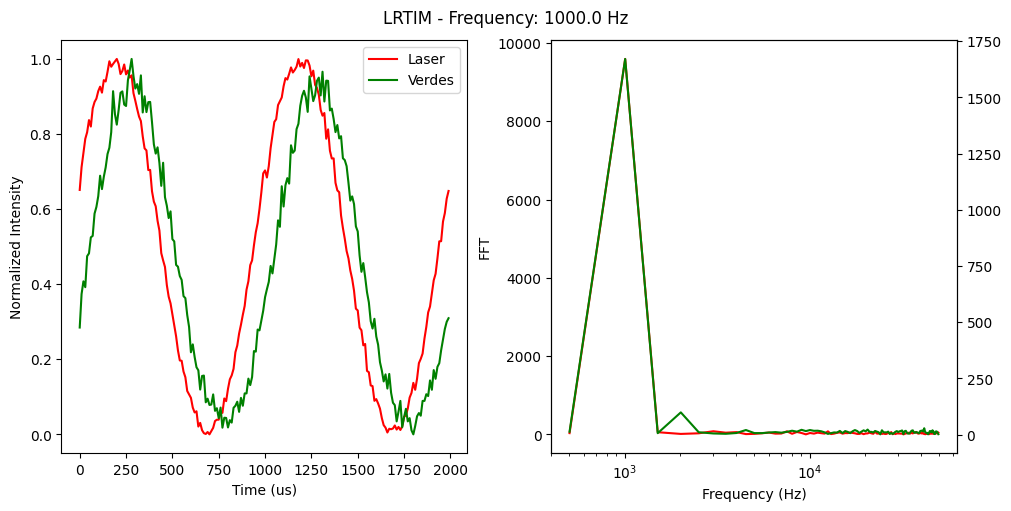

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

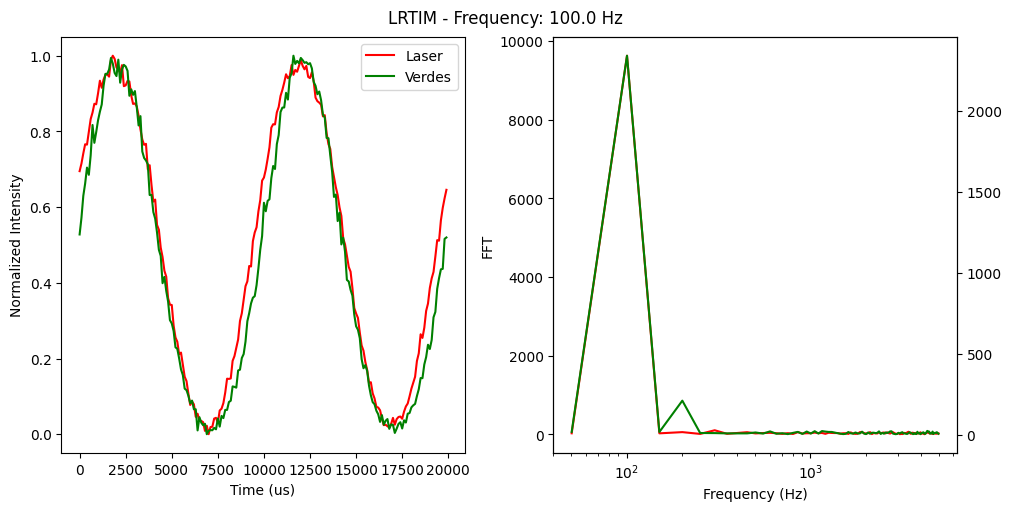

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

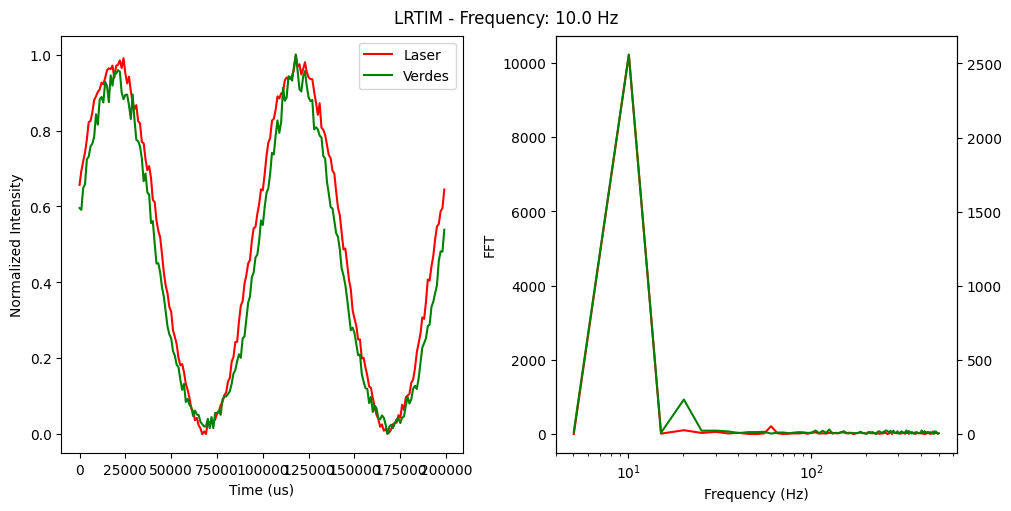

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

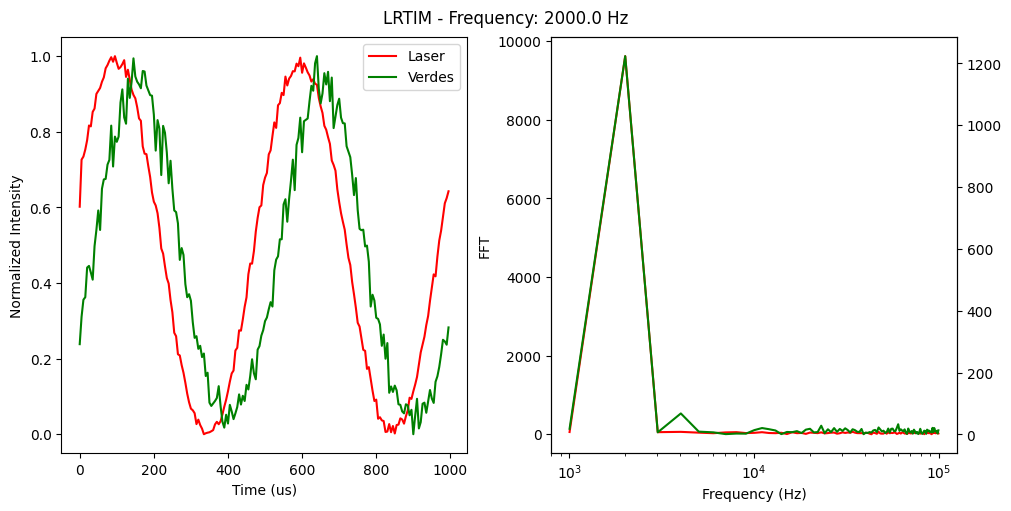

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

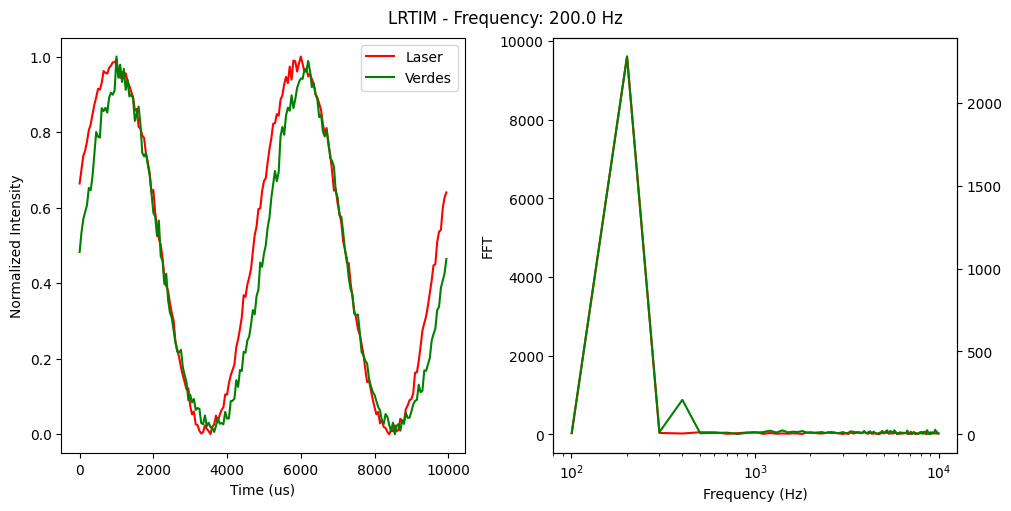

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

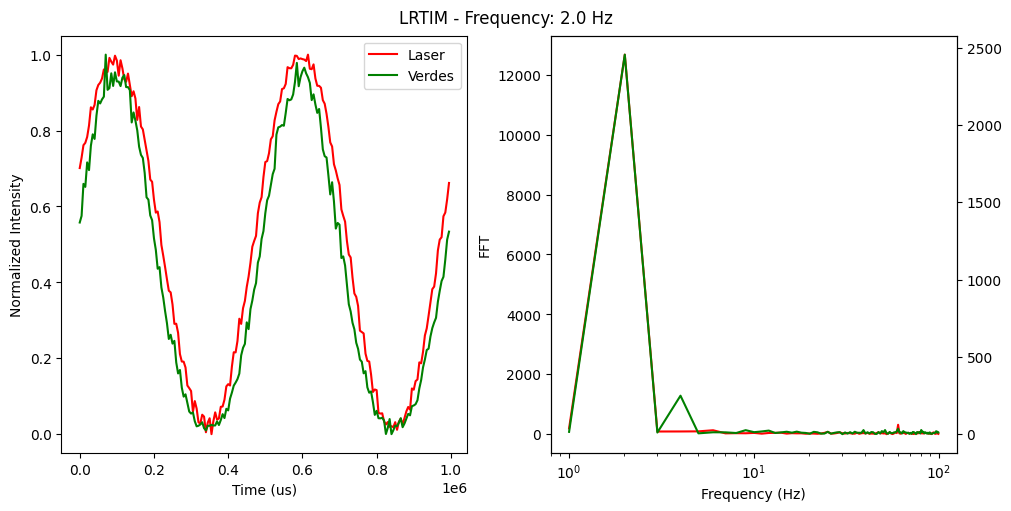

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

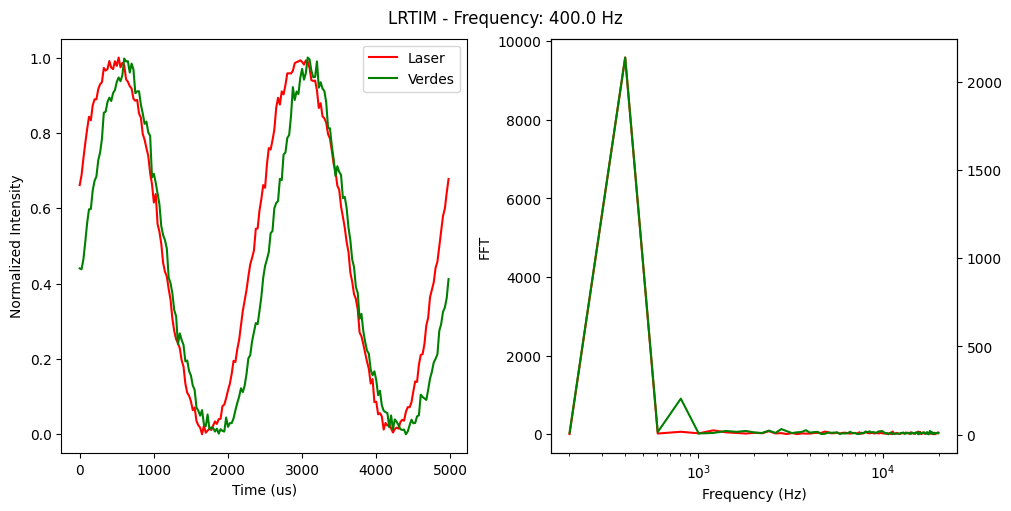

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

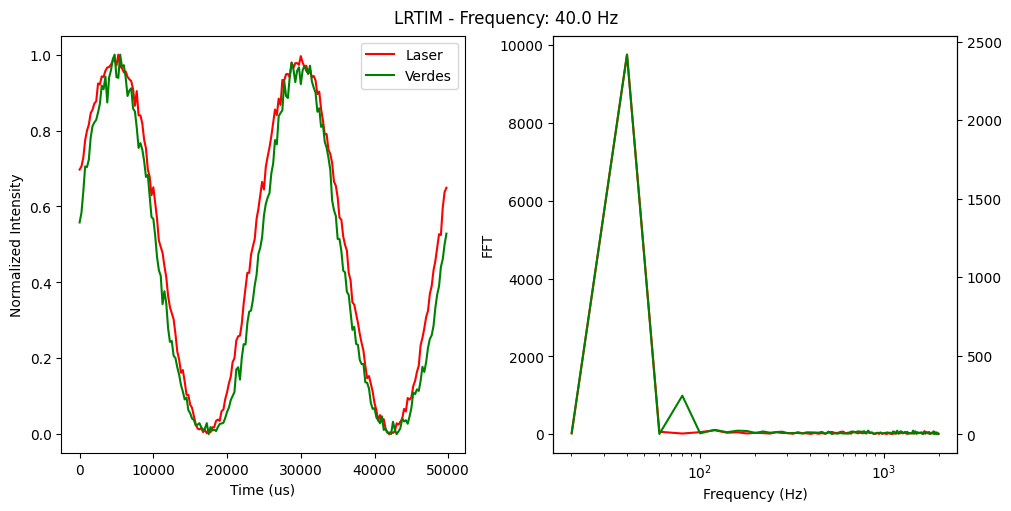

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

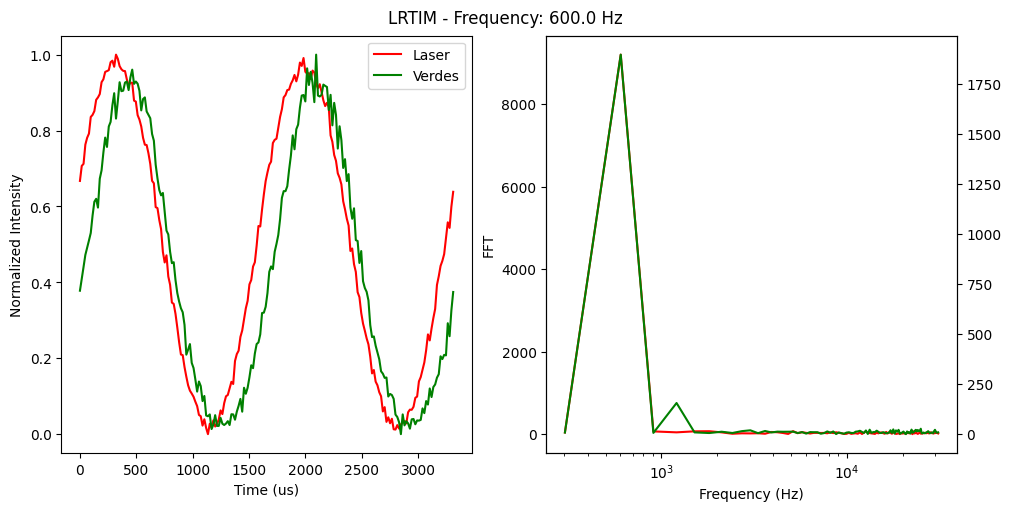

<IPython.core.display.Javascript object>

In [ ]:
tb = widgets.TabBar([str(freq) for freq in sorted(verdes_LRTIM.keys())])

for freq in verdes_LRTIM.keys():
  with tb.output_to(str(freq)):
    time = laser_LRTIM[freq][:, 0]
    laser_curve = laser_LRTIM[freq][:, 1]
    verdes_curve = verdes_LRTIM[freq][:, 1]

    fig, ax = plt.subplots(1,2, figsize=(10, 5), constrained_layout = True)
    ax[0].plot(time, (laser_curve-min(laser_curve))/(max(laser_curve)-min(laser_curve)), label='Laser', color='red')
    ax[0].plot(time, (verdes_curve-min(verdes_curve))/(max(verdes_curve)-min(verdes_curve)), label='Verdes', color='green')

    xf_laser, yf_laser = get_fft(freq, time, laser_curve)
    xf_verdes, yf_verdes = get_fft(freq, time, verdes_curve)

    N = len(yf_laser)//2
    ax[1].plot(xf_laser[1:N], np.abs(yf_laser[1:N]) / N * 2, label='Laser', color='red')
    ax2 = ax[1].twinx()
    ax2.plot(xf_verdes[1:N], np.abs(yf_verdes[1:N]) / N * 2, label='Verdes', color='green')

    fig.suptitle(f'LRTIM - Frequency: {freq} Hz')
    ax[0].set_xlabel('Time (us)')
    ax[0].set_ylabel('Normalized Intensity')
    ax[0].legend()

    ax[1].set_xlabel('Frequency (Hz)')
    ax[1].set_ylabel('FFT')
    ax[1].set_xscale('log')

## Using the General-Purpose Timer (GPTIM)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

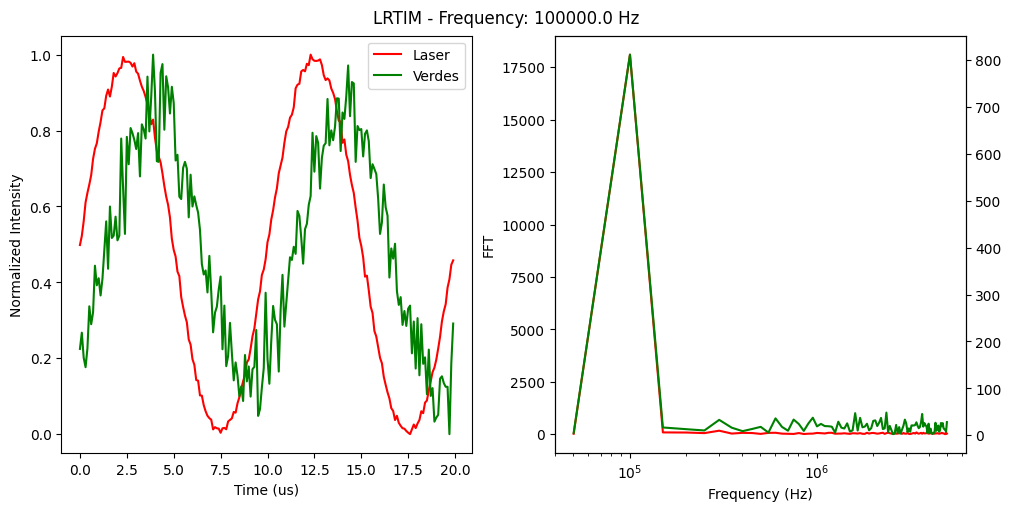

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

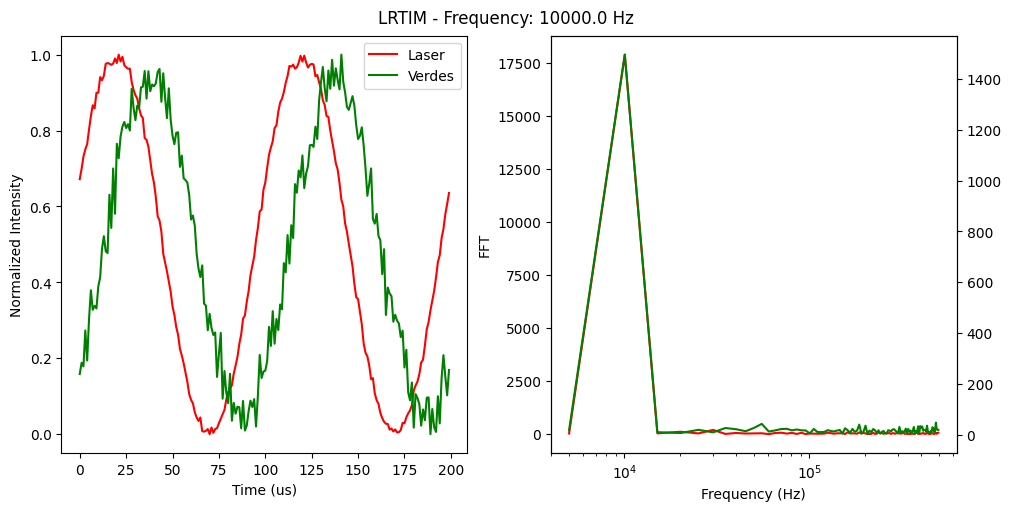

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

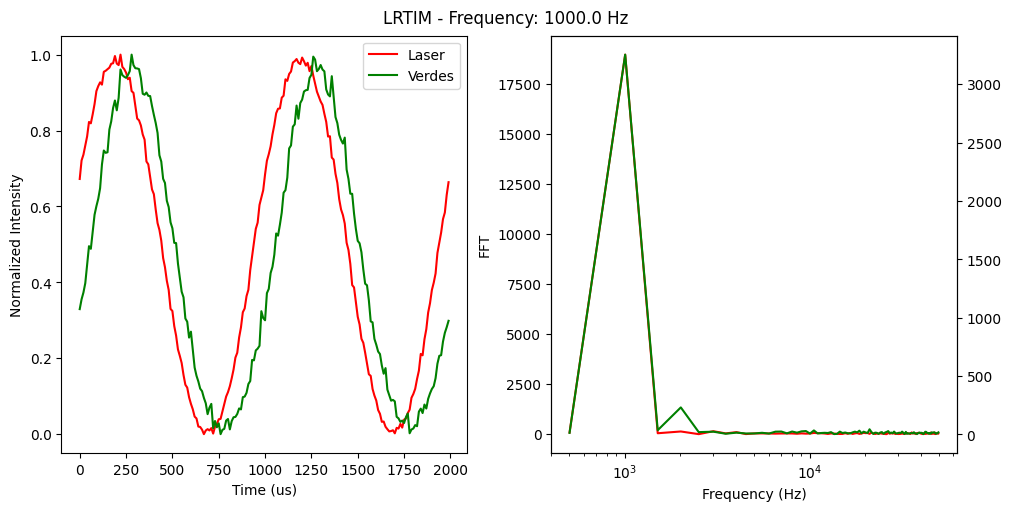

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

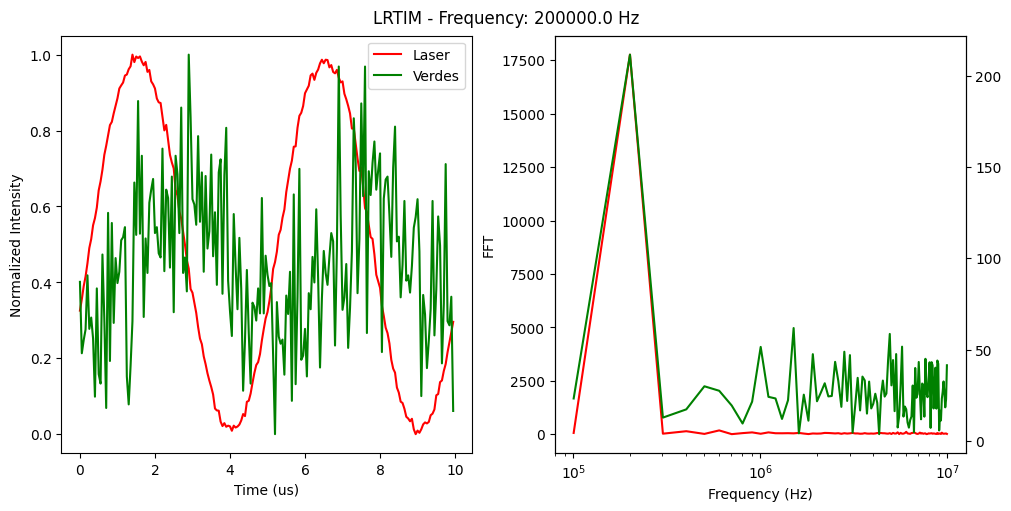

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

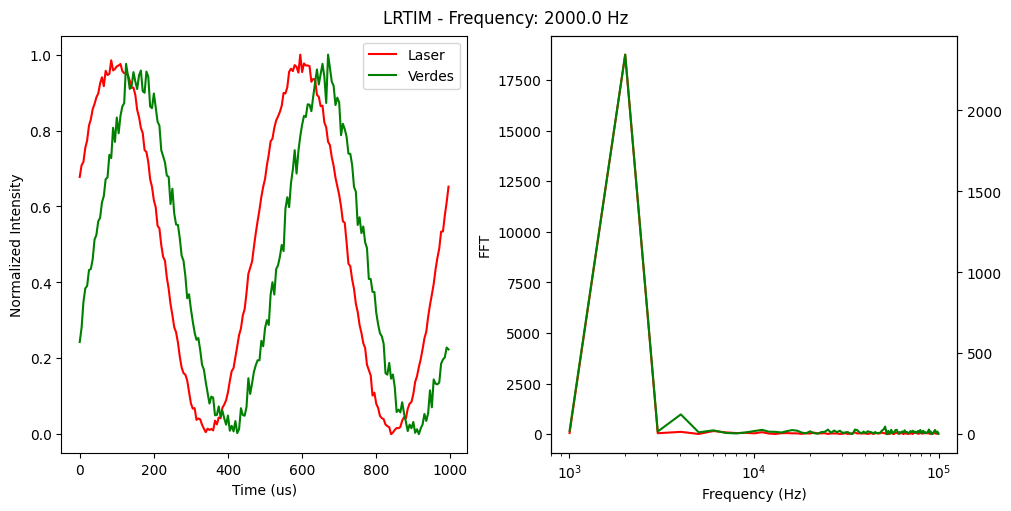

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

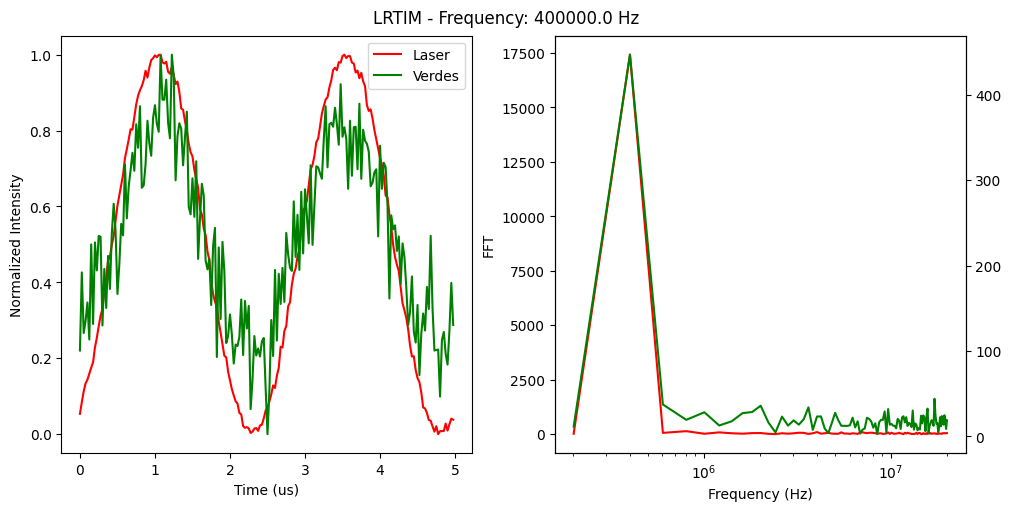

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

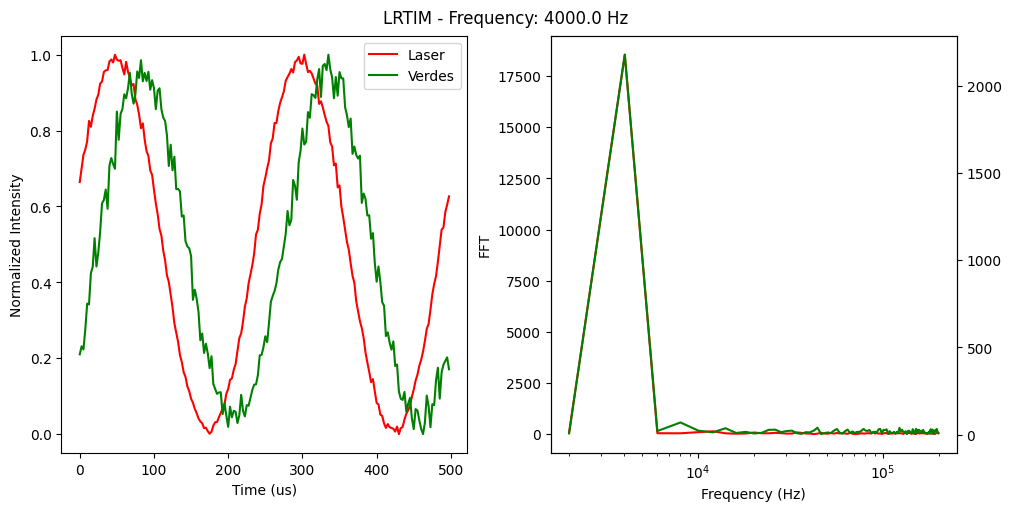

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

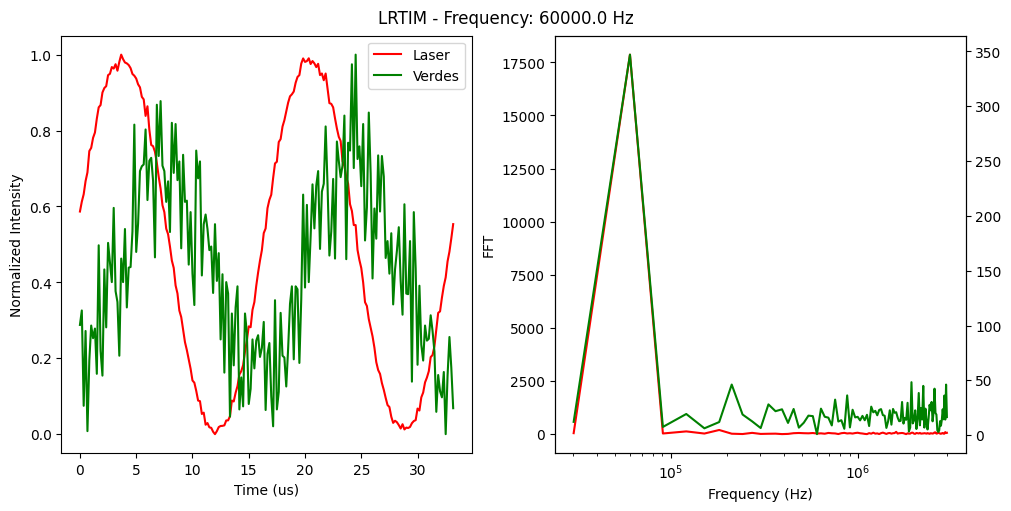

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

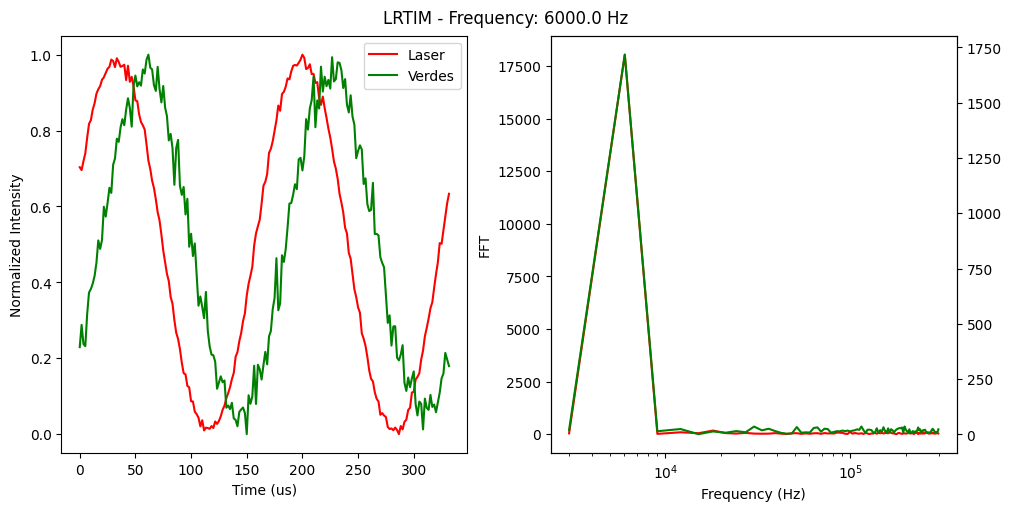

<IPython.core.display.Javascript object>

In [ ]:
tb = widgets.TabBar([str(freq) for freq in sorted(verdes_GPTIM.keys())])

for freq in verdes_GPTIM.keys():
  with tb.output_to(str(freq)):
    time = laser_GPTIM[freq][:, 0]
    laser_curve = laser_GPTIM[freq][:, 1]
    verdes_curve = verdes_GPTIM[freq][:, 1]

    fig, ax = plt.subplots(1,2, figsize=(10, 5), constrained_layout = True)
    ax[0].plot(time, (laser_curve-min(laser_curve))/(max(laser_curve)-min(laser_curve)), label='Laser', color='red')
    ax[0].plot(time, (verdes_curve-min(verdes_curve))/(max(verdes_curve)-min(verdes_curve)), label='Verdes', color='green')

    xf_laser, yf_laser = get_fft(freq, time, laser_curve)
    xf_verdes, yf_verdes = get_fft(freq, time, verdes_curve)

    N = len(yf_laser)//2
    ax[1].plot(xf_laser[1:N], np.abs(yf_laser[1:N]) / N * 2, label='Laser', color='red')
    ax2 = ax[1].twinx()
    ax2.plot(xf_verdes[1:N], np.abs(yf_verdes[1:N]) / N * 2, label='Verdes', color='green')

    fig.suptitle(f'LRTIM - Frequency: {freq} Hz')
    ax[0].set_xlabel('Time (us)')
    ax[0].set_ylabel('Normalized Intensity')
    ax[0].legend()

    ax[1].set_xlabel('Frequency (Hz)')
    ax[1].set_ylabel('FFT')
    ax[1].set_xscale('log')

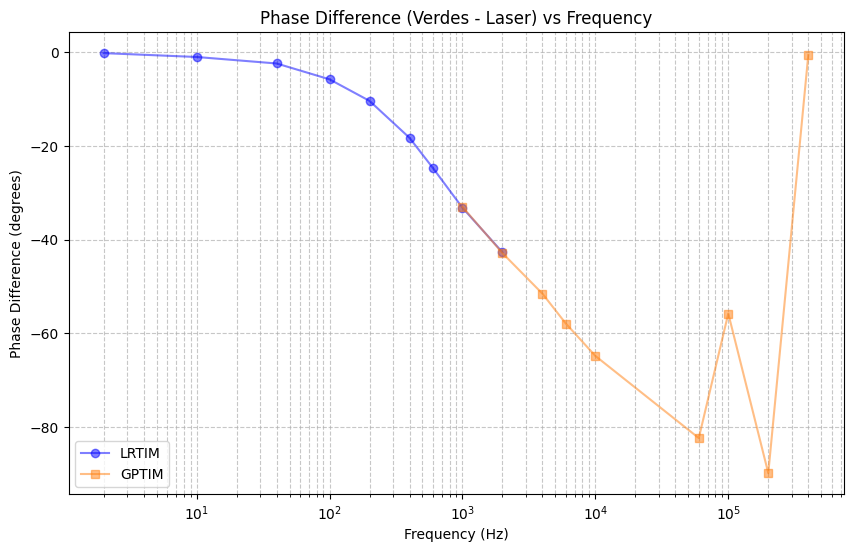

In [ ]:
def get_phase_diff(data_dict):
    freqs = sorted(data_dict.keys())
    phase_diffs = []

    for f in freqs:
        if data_dict is verdes_LRTIM:
            l_data = laser_LRTIM[f][:, 1]
            v_data = verdes_LRTIM[f][:, 1]
        else:
            l_data = laser_GPTIM[f][:, 1]
            v_data = verdes_GPTIM[f][:, 1]

        # FFT
        l_fft = np.fft.fft(l_data - np.mean(l_data))
        v_fft = np.fft.fft(v_data - np.mean(v_data))

        # Find the peak frequency index (the modulation frequency)
        idx = np.argmax(np.abs(l_fft[:len(l_fft)//2]))

        # Calculate phase difference in degrees
        l_phase = np.angle(l_fft[idx])
        v_phase = np.angle(v_fft[idx])

        diff = np.degrees(v_phase - l_phase)
        # Normalize to [-180, 180]
        diff = (diff + 180) % 360 - 180
        phase_diffs.append(diff)

    return freqs, phase_diffs

f_lrtim, p_lrtim = get_phase_diff(verdes_LRTIM)
f_gptim, p_gptim = get_phase_diff(verdes_GPTIM)

plt.figure(figsize=(10, 6))
plt.plot(f_lrtim, p_lrtim, 'o-', label='LRTIM', color='blue', alpha=0.5)
plt.plot(f_gptim, p_gptim, 's-', label='GPTIM', color='tab:orange', alpha=0.5)
plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase Difference (degrees)')
plt.title('Phase Difference (Verdes - Laser) vs Frequency')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Longer acquisition times may lead to increased contribution of laser leackage ?

# Gemini

In [ ]:
# --- Célula de Importação ---
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy import signal as sig
from scipy.optimize import curve_fit
from scipy.integrate import odeint, trapezoid
from scipy.fft import fft, fftfreq

# Substituindo widgets do Colab por ipywidgets padrão do Jupyter
import ipywidgets as widgets
from IPython.display import display, clear_output

np.seterr('warn')

kB = 0.695034 #cm^-1 / K  #Boltzmann's Constant
hc = 1.98644568e-25 # J.m  #Planck's Constant

# --- Configuração do Caminho (Ajuste aqui!) ---
# No Linux/Ubuntu, use o caminho absoluto ou relativo da sua pasta local
# Exemplo: data_path = './dados_experimento/'
data_path = 'CAMINHO_PARA_SUA_PASTA_LOCAL_AQUI' 

# --- Função de FFT (Mantida igual) ---
def get_fft(freq, time, curve):
    sample_interval = max(time)/len(curve)/1e6  # seconds per sample
    N = len(curve)
    yf = fft(curve)
    xf = fftfreq(N, sample_interval)
    return xf, yf

# --- Carregamento de Arquivos ---
folder_to_scan = data_path
filenames_all = sorted([
    fname for fname in os.listdir(folder_to_scan)
    if os.path.isfile(os.path.join(folder_to_scan, fname))
])

# Processamento dos dicionários (Mantido igual)
laser_GPTIM = {float(fn.split('_')[1].replace('Hz', '')): np.loadtxt(os.path.join(folder_to_scan, fn)) for fn in filenames_all if ('laser' in fn and 'GPTIM' in fn)}
laser_LRTIM = {float(fn.split('_')[1].replace('Hz', '')): np.loadtxt(os.path.join(folder_to_scan, fn)) for fn in filenames_all if ('laser' in fn and 'LRTIM' in fn)}
verdes_GPTIM = {float(fn.split('_')[1].replace('Hz', '')): np.loadtxt(os.path.join(folder_to_scan, fn)) for fn in filenames_all if ('verdes' in fn and 'GPTIM' in fn)}
verdes_LRTIM = {float(fn.split('_')[1].replace('Hz', '')): np.loadtxt(os.path.join(folder_to_scan, fn)) for fn in filenames_all if ('verdes' in fn and 'LRTIM' in fn)}

# --- Visualização com Interatividade Local (Substituindo TabBar) ---
def plot_data(freq):
    time = laser_LRTIM[freq][:, 0]
    laser_curve = laser_LRTIM[freq][:, 1]
    verdes_curve = verdes_LRTIM[freq][:, 1]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    
    # Plot no tempo
    ax[0].plot(time, (laser_curve-min(laser_curve))/(max(laser_curve)-min(laser_curve)), label='Laser', color='red')
    ax[0].plot(time, (verdes_curve-min(verdes_curve))/(max(verdes_curve)-min(verdes_curve)), label='Verdes', color='green')
    ax[0].set_xlabel('Time (us)')
    ax[0].set_ylabel('Normalized Intensity')
    ax[0].legend()

    # Plot FFT
    xf_laser, yf_laser = get_fft(freq, time, laser_curve)
    xf_verdes, yf_verdes = get_fft(freq, time, verdes_curve)
    N = len(yf_laser)//2
    
    ax[1].plot(xf_laser[1:N], np.abs(yf_laser[1:N]) / N * 2, label='Laser', color='red')
    ax2 = ax[1].twinx()
    ax2.plot(xf_verdes[1:N], np.abs(yf_verdes[1:N]) / N * 2, label='Verdes', color='green')
    
    ax[1].set_xlabel('Frequency (Hz)')
    ax[1].set_ylabel('FFT')
    ax[1].set_xscale('log')
    fig.suptitle(f'LRTIM - Frequency: {freq} Hz')
    plt.show()

# Criando um menu dropdown (mais estável no Jupyter local que abas CSS)
freq_options = sorted(verdes_LRTIM.keys())
widgets.interact(plot_data, freq=freq_options);